In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(12,6)

In [2]:
fund = pd.read_csv("../data/processed/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/processed/05_category_inflows.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

category["month"] = pd.to_datetime(category["month"])

folio["month"] = pd.to_datetime(folio["month"])

In [4]:
fund = pd.read_csv("../data/processed/01_fund_master.csv")

# If nav is already loaded
nav = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'scheme_name'], dtype='object')


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

In [ ]:
# Top 10 schemes by latest NAV
latest = (
    nav.sort_values("date")
       .groupby("scheme_name")
       .tail(1)
       .sort_values("nav", ascending=False)
)

top10 = latest["scheme_name"].head(10)

nav_top = nav[nav["scheme_name"].isin(top10)]

fig = px.line(
    nav_top,
    x="date",
    y="nav",
    color="scheme_name",
    title="Top 10 Mutual Fund NAV Trends (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    annotation_text="Correction"
)

fig.update_layout(
    width=1400,
    height=700,
    legend_title="Scheme"
)

fig.show()
plt.savefig(
    "../reports/chart.png",
    dpi=300,
    bbox_inches="tight"
)


In [10]:
nav_norm = nav.copy()

nav_norm["normalized_nav"] = (
    nav_norm.groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

fig = px.line(
    nav_norm,
    x="date",
    y="normalized_nav",
    color="scheme_name",
    title="Normalized NAV Performance (Base = 100)"
)

fig.show()
plt.savefig(
    "../reports/chart.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 1200x600 with 0 Axes>

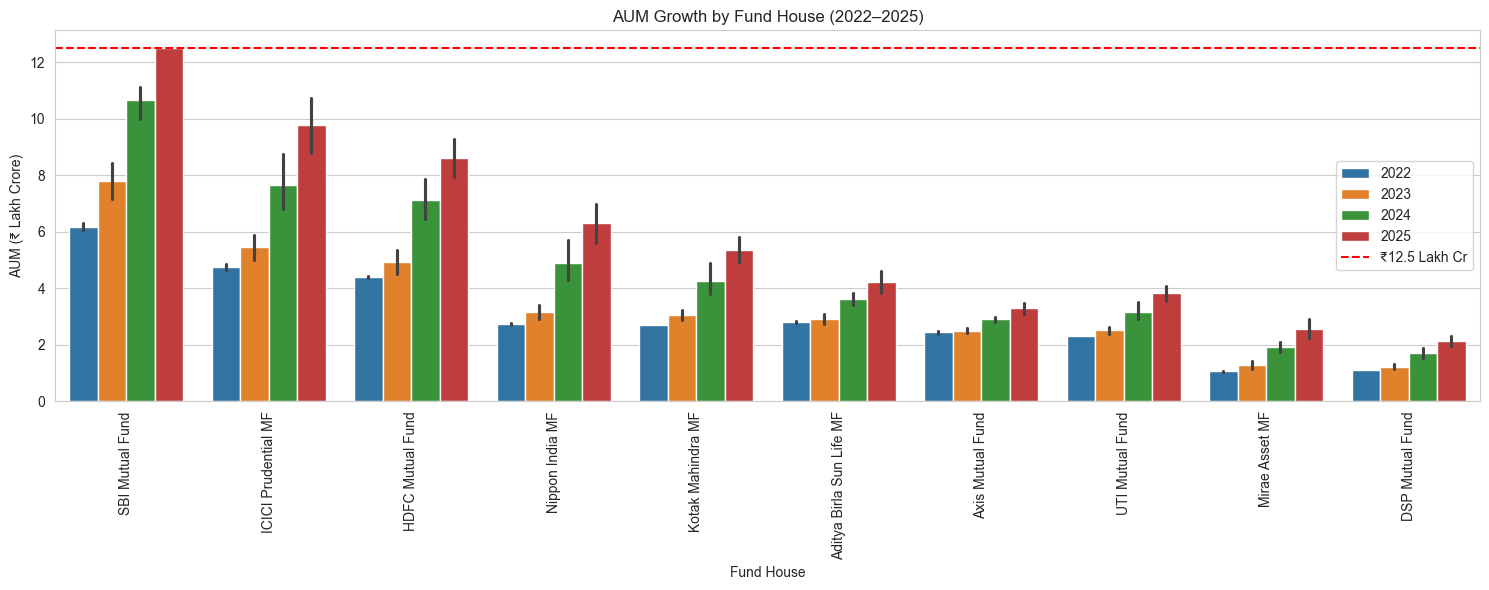

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year.astype(str)

plt.figure(figsize=(15,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=90)

plt.axhline(
    y=12.5,
    color="red",
    linestyle="--",
    label="₹12.5 Lakh Cr"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.legend()

plt.tight_layout()
plt.savefig("../reports/aum_growth.png", dpi=300)
plt.show()

In [13]:
import plotly.express as px

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow (2022–2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr",
    showarrow=True
)

fig.show()

# fig.write_image("../reports/sip_trend.png")

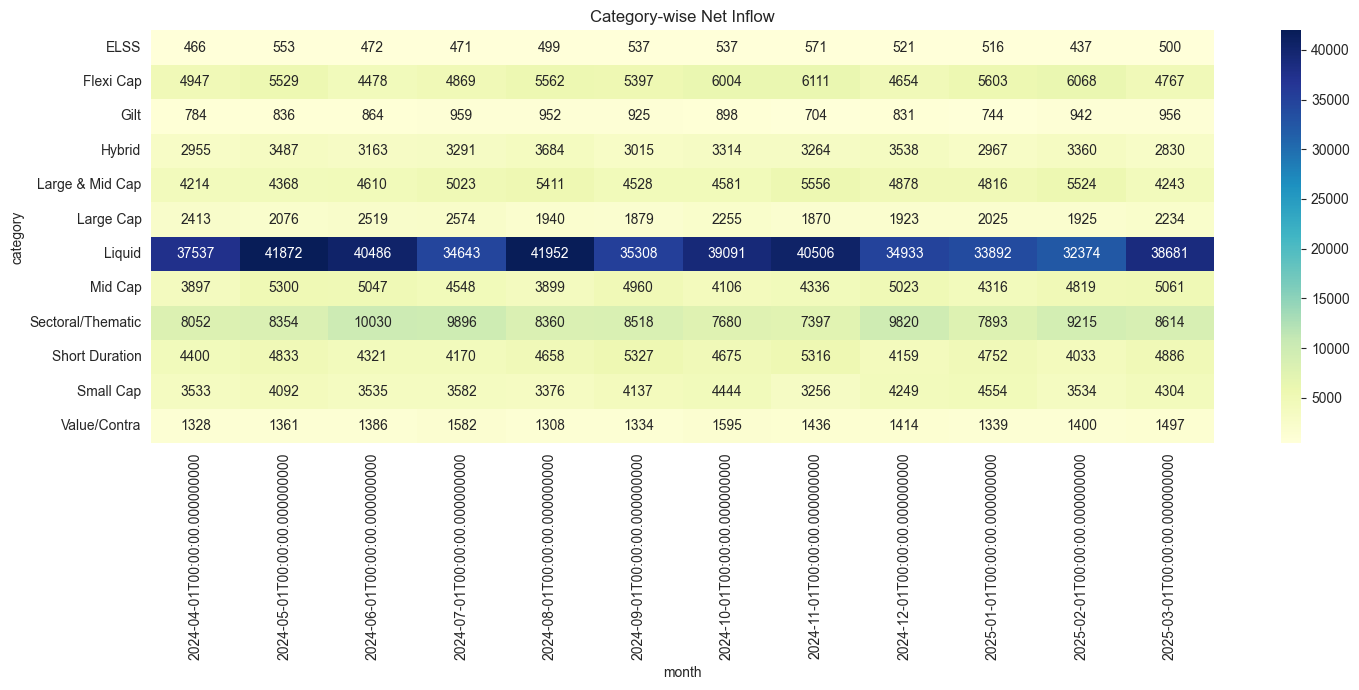

In [14]:
pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

plt.figure(figsize=(15,7))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflow")

plt.tight_layout()
plt.savefig("../reports/category_heatmap.png", dpi=300)
plt.show()

In [16]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

In [18]:
import pandas as pd

investors = pd.read_csv("../data/raw/08_investor_transactions.csv")

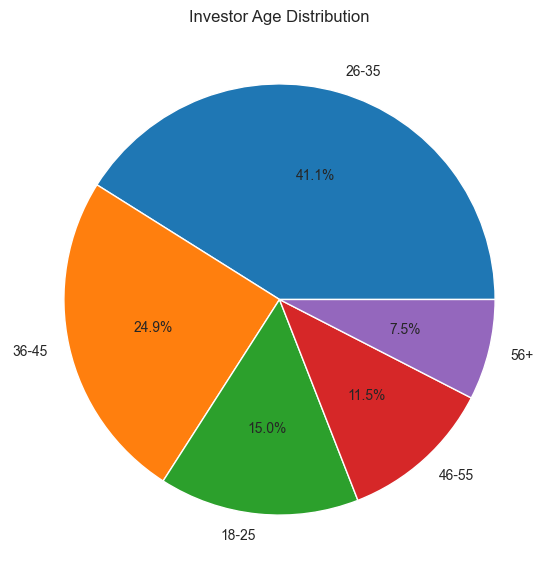

In [19]:
plt.figure(figsize=(7,7))

investors["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Investor Age Distribution")

plt.savefig("../reports/age_distribution.png", dpi=300)
plt.show()


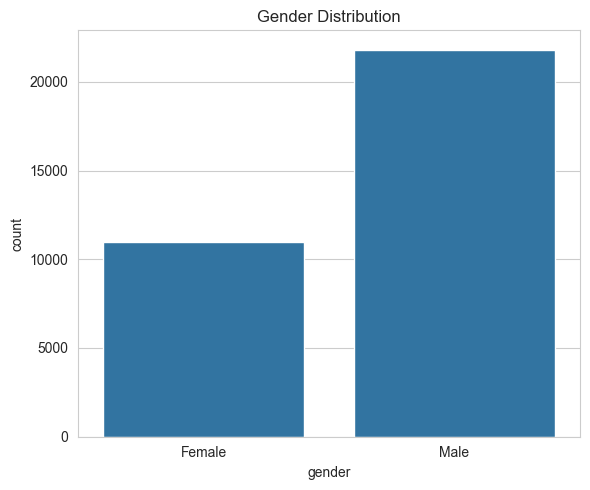

In [20]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=investors,
    x="gender"
)

plt.title("Gender Distribution")

plt.tight_layout()

plt.savefig("../reports/gender_split.png", dpi=300)

plt.show()

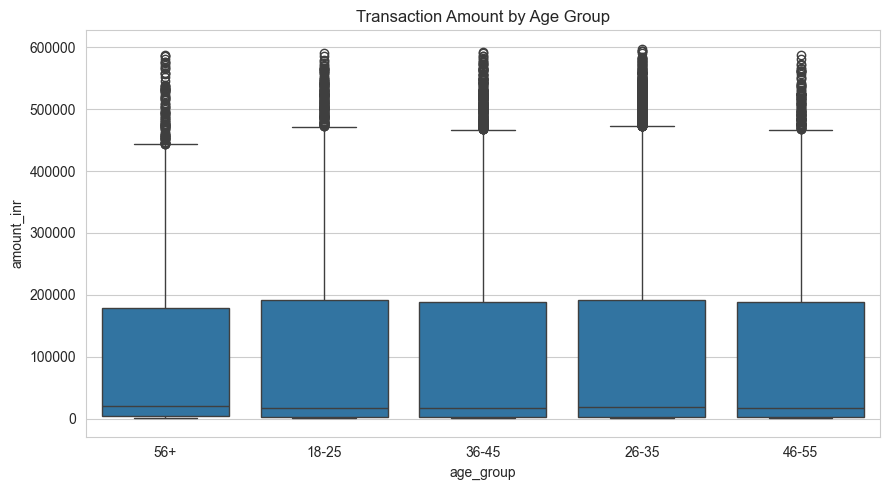

In [21]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=investors,
    x="age_group",
    y="amount_inr"
)

plt.title("Transaction Amount by Age Group")

plt.tight_layout()

plt.savefig("../reports/transaction_boxplot.png", dpi=300)

plt.show()

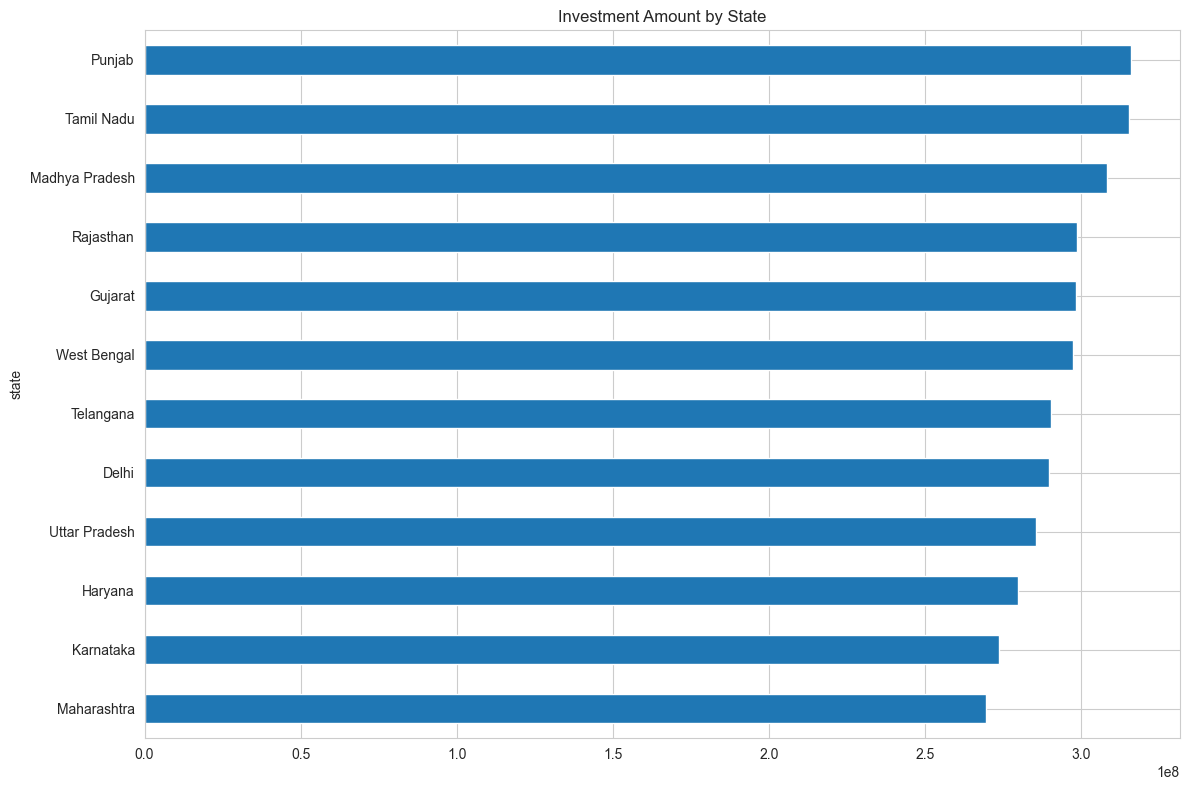

In [22]:
state = investors.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(12,8))

state.plot(kind="barh")

plt.title("Investment Amount by State")

plt.tight_layout()

plt.savefig("../reports/state_distribution.png", dpi=300)

plt.show()

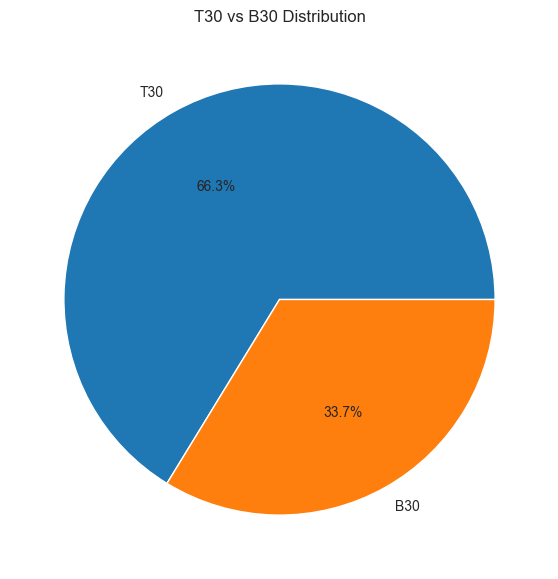

In [23]:
plt.figure(figsize=(7,7))

investors["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("T30 vs B30 Distribution")

plt.savefig("../reports/city_tier.png", dpi=300)

plt.show()

In [24]:
folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry Folio Growth"
)

fig.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="13.26 Cr"
)

fig.add_annotation(
    x="2025-12-01",
    y=26.12,
    text="26.12 Cr"
)

fig.show()

# fig.write_image("../reports/folio_growth.png")

In [28]:
import pandas as pd

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav_merge = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_merge.columns.tolist())

['amfi_code', 'date', 'nav', 'scheme_name']


In [29]:
pivot = nav_merge.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav",
    aggfunc="mean"
)

returns = pivot.pct_change().dropna()
corr = returns.iloc[:, :10].corr()

In [30]:
print(fund_master.columns.tolist())
print(nav_merge.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
['amfi_code', 'date', 'nav', 'scheme_name']


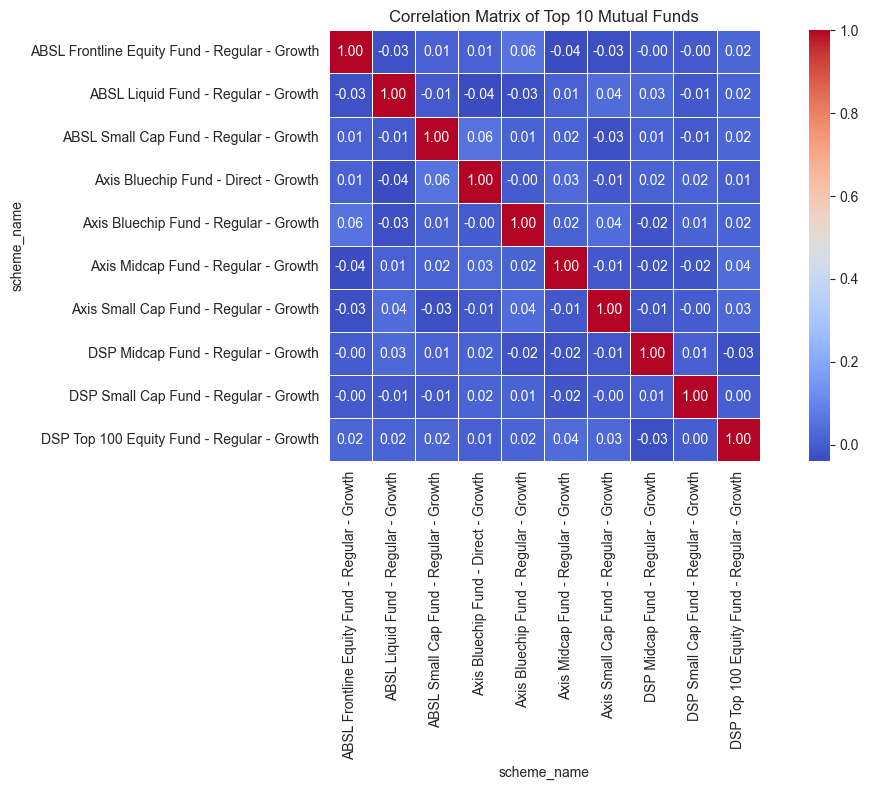

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure date is datetime
nav_merge["date"] = pd.to_datetime(nav_merge["date"])

# Create pivot table
pivot = nav_merge.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav",
    aggfunc="mean"
)

# Daily returns
returns = pivot.pct_change().dropna()

# Select first 10 schemes
corr = returns.iloc[:, :10].corr()

# Plot
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Top 10 Mutual Funds")
plt.tight_layout()
plt.savefig("../reports/correlation_matrix.png", dpi=300)
plt.show()

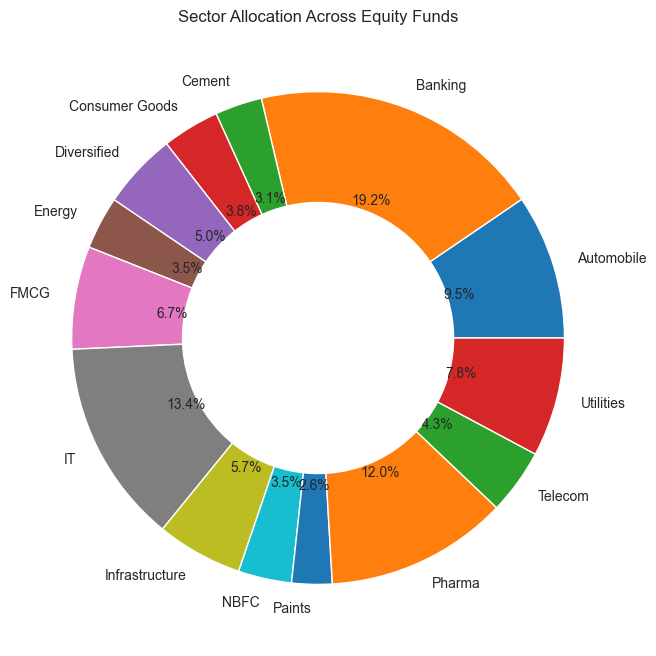

In [32]:
sector = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.45)
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig("../reports/sector_allocation.png", dpi=300)

plt.show()